<a href="https://colab.research.google.com/github/anyavaniprakash-spec/dsrp_Arms-Tranfers/blob/main/dsrp_Day_1-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UPLOADING DATA

In [2]:
import pandas as pd
import csv
import io

In [3]:
url = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Arms%20Transfers/arms_transfers_clean.csv'
df = pd.read_csv(url)

In [4]:
df.head()

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4


BASIC DATAFRAME FUNCTIONS

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9756 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9756 non-null   object 
 1   Supplier                        9756 non-null   object 
 2   Year of order                   9756 non-null   int64  
 3   Number ordered                  9670 non-null   float64
 4   Weapon designation              9756 non-null   object 
 5   Weapon description              9756 non-null   object 
 6   Deliveries in the Year Range    9333 non-null   float64
 7   Year(s) of delivery             9333 non-null   object 
 8   status                          9756 non-null   object 
 9   SIPRI TIV per unit              9756 non-null   float64
 10  SIPRI TIV for total order       9756 non-null   float64
 11  SIPRI TIV of delivered weapons  9756 non-null   float64
dtypes: float64(5), int64(1), object(6)

,Year of order,Number ordered,Deliveries in the Year Range,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,9756.000000,9670.000000,9333.000000,9756.000000,9756.000000,9756.000000
mean,1987.274703,156.860703,154.585664,7.443830,94.357230,83.811894
std,22.060454,987.060460,997.650698,23.468209,337.544437,303.717951
min,1940.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1969.000000,3.000000,3.000000,0.240000,5.000000,4.200000
50%,1986.000000,12.000000,12.000000,1.000000,18.000000,16.000000
75%,2008.000000,60.000000,57.000000,5.000000,56.000000,52.575000
max,2025.000000,50000.000000,50000.000000,700.000000,10117.500000,10117.500000


FINDING NULL VALUES AND REPLACING THEM WITH NaN

In [6]:
df.isnull().value_counts()

Recipient  Supplier  Year of order  Number ordered  Weapon designation  Weapon description  Deliveries in the Year Range  Year(s) of delivery  status  SIPRI TIV per unit  SIPRI TIV for total order  SIPRI TIV of delivered weapons
False      False     False          False           False               False               False                         False                False   False               False                      False                             9296
                                                                                            True                          True                 False   False               False                      False                              374
                                    True            False               False               True                          True                 False   False               False                      False                               49
                                                                                            False                         False                False   False               False                      False                               37
Name: count, dtype: int64

In [7]:
df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,86
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,423
Year(s) of delivery,423
status,0
SIPRI TIV per unit,0


In [8]:
import numpy as np
df['Number ordered'] = pd.to_numeric(df['Number ordered'], errors='coerce')
df['Deliveries in the Year Range'] = pd.to_numeric(df['Deliveries in the Year Range'], errors='coerce')
df['Year(s) of delivery'] = pd.to_numeric(df['Year(s) of delivery'], errors='coerce')


In [9]:
df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,86
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,423
Year(s) of delivery,4834
status,0
SIPRI TIV per unit,0


In [10]:
df.dtypes

,0
Recipient,object
Supplier,object
Year of order,int64
Number ordered,float64
Weapon designation,object
Weapon description,object
Deliveries in the Year Range,float64
Year(s) of delivery,float64
status,object
SIPRI TIV per unit,float64


ok... so initially we changed null values to 'N/A' but this messed up the data type in the colums. instead, we changed the null values to NaN which means not a number. so there will still be a lot of null values in this dataset BUT the computer will skip over these values when computing any math operations, etc. so even though there are null values, it shouldn't get in the way of any operations or model statistics. we have to first preserve the data type as a float and we did that so yay!

This cell just checks to make sure the null values show up as NaN. We checked this for all three rows that had null values and had float or int as their datatype.

In [11]:
# 1. Check the true data type
print("Data Type:", df['Year(s) of delivery'].dtype)

# 2. Check the exact count of missing values
print("Total Nulls:", df['Year(s) of delivery'].isnull().sum())

# 3. Look at a few rows where the data IS null
print("\nSample of Null Rows:")
print(df[df['Year(s) of delivery'].isnull()]['Year(s) of delivery'].head())


Data Type: float64
Total Nulls: 4834

Sample of Null Rows:
2   NaN
3   NaN
4   NaN
5   NaN
7   NaN
Name: Year(s) of delivery, dtype: float64


DROPPING DUPLICATED ROWS

In [12]:
df.duplicated().sum()

np.int64(17)

In [13]:
df[df.duplicated()]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
560,Bahrain,United States,1985,6.0,F-5E Tiger-2,fighter/ground-attack aircraft,6.0,NaN,New,10.50,63.00,63.00
1463,Colombia,United States,2010,1.0,King Air,light transport aircraft,1.0,2011.0,New,2.85,2.85,2.85
1903,Ecuador,United States,1980,1.0,King Air,light transport aircraft,1.0,1981.0,New,2.85,2.85,2.85
2141,Egypt,United States,1982,300.0,AIM-9L Sidewinder,short-range air-to-air missile,300.0,1983.0,New,0.11,33.00,33.00
2205,El Salvador,United States,1977,1.0,DC-6/C-118,transport aircraft,1.0,1977.0,Second hand,3.40,3.40,3.40
4328,Japan,United States,2001,16.0,SM-2MR,surface-to-air missile,16.0,2003.0,New,0.30,4.80,4.80
4938,Mexico,United States,2008,4.0,aircraft engine,aircraft engine,4.0,2010.0,New,0.50,2.00,2.00
5023,Mexico,United States,2010,3.0,S-70 Black Hawk,transport helicopter,3.0,2011.0,New,7.25,21.75,21.75
5277,Netherlands,United States,2009,14.0,vehicle engine,vehicle engine,14.0,2009.0,New,0.03,0.42,0.42
5340,Netherlands,United States,2023,NaN,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,NaN,NaN,New,0.05,0.00,0.00


In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df.duplicated()]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons


In [17]:
df.rename(columns={'Year of order': 'Year of Order', 'Number ordered': 'Number Ordered', 'Weapon designation': 'Weapon Designation', 'Weapon description': 'Weapon Description', 'status': 'Status'}, inplace=True)
print(df.columns)


Index(['Recipient', 'Supplier', 'Year of Order', 'Number Ordered',
       'Weapon Designation', 'Weapon Description',
       'Deliveries in the Year Range', 'Year(s) of delivery', 'Status',
       'SIPRI TIV per unit', 'SIPRI TIV for total order',
       'SIPRI TIV of delivered weapons'],
      dtype='object')


In [18]:
df.columns.value_counts()

,count
Recipient,1
Supplier,1
Year of Order,1
Number Ordered,1
Weapon Designation,1
Weapon Description,1
Deliveries in the Year Range,1
Year(s) of delivery,1
Status,1
SIPRI TIV per unit,1


In [19]:
# At this point:
# we have dropped duplicate rows
# we have replaced null values with NaN (dropping them would lose lots of potentially valuable data)
# we have revised column names to be cohesive
# we have done basic functions of the dataset including .info and .describe

# NEXT:
# make some comparison statements
# create some data visualizations
# figure out certain trends / patterns in areas of interest -- this will inform research questions and further cleaning of the dataset for potential ML models

# potential ideas rn: comparing US supply to Israel and Ukraine // comparing US supply based on presidency (seperate data by years)
# // looking at trend of weapons supply by the US in general (should do this anyway in data vis phase)

DATA COMPARISON STATEMENTS + DATA VISUALIZATIONS

first tho do lit review to narrow down operations....

Lit review findings here:

-"After Russia’s invasion in February 2022, Ukraine became by far the top recipient of U.S. foreign aid, marking the first time a European country held the top spot since the Marshall Plan directed vast sums to rebuild the continent after World War II. Yet, U.S. commitment to Ukraine has been called into question under the second Trump administration and there has been no significant aid legislation since 2024." cfr.org

Day 2----->

In [20]:
df.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015.0,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005.0,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,NaN,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,NaN,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,NaN,New,0.40,16.4,16.4


looking at dataframe in year order

In [30]:
df.sort_values(by='Year of Order', ascending=False).head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
3467,Israel,United States,2025,2166.0,GBU-39 SDB,guided glide bomb,100.0,2025.0,New,0.02,43.32,2.0
8874,Ukraine,United States,2025,NaN,AGM-114L Hellfire Longbow,anti-tank missile,100.0,2025.0,New,0.07,0.00,7.0
8875,Ukraine,United States,2025,NaN,GMLRS,guided rocket,200.0,2025.0,Second hand,0.03,0.00,6.4
8876,Ukraine,United States,2025,NaN,Tempest SAM,mobile surface-to-air missile system,5.0,2025.0,New,1.00,0.00,5.0
3682,Israel,United States,2025,5000.0,JDAM,guided bomb,NaN,NaN,New,0.02,100.00,0.0


creating a dataframe with only rows from the 21st century...

In [112]:
df_this_century = df[df['Year of Order']>=2000].sort_values(by='Year of Order', ascending=False)

In [113]:
print (df_this_century['Number Ordered'].mean())
print (df_this_century['Number Ordered'].min())
print (df_this_century['Number Ordered'].max())
print (df_this_century['Deliveries in the Year Range'].mean())
print (df_this_century['Deliveries in the Year Range'].min())
print (df_this_century['Deliveries in the Year Range'].max())

201.2296786389414
1.0
29500.0
199.03630595699684
1.0
29500.0


data vis inmports

In [167]:
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


data visual shows the top ten countries with highest count of orders

In [142]:
df_this_century.groupby('Recipient')['Number Ordered'].sum().nlargest(10)

,Number Ordered
Recipient,
Ukraine,81002.0
Saudi Arabia,76426.0
Israel,67136.0
United Arab Emirates,46975.0
Iraq,26376.0
Australia,24754.0
Afghanistan,22782.0
Poland,22688.0
United States,22223.0


In [143]:
data = df_this_century.groupby('Recipient')['Number Ordered'].sum().nlargest(10)

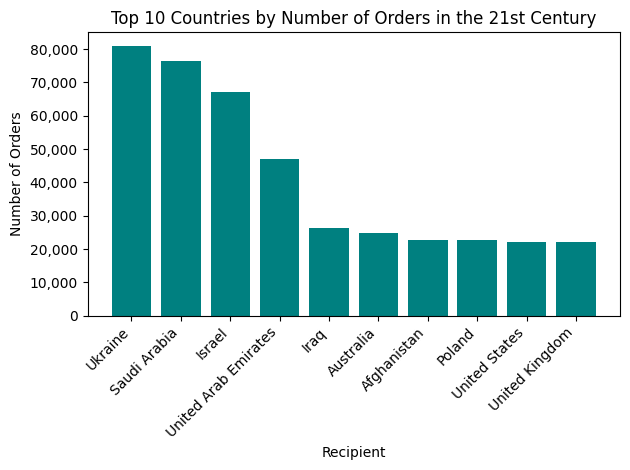

In [220]:
plt.bar(data.index, data.values, color = 'teal')
plt.xlabel('Recipient')
plt.ylabel('Number of Orders')
plt.title('Top 10 Countries by Number of Orders in the 21st Century')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()

data visual shows top ten countries with highest count of deliveries

In [146]:
df_this_century.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Ukraine,110913.0
Saudi Arabia,75177.0
United Arab Emirates,46873.0
Israel,46280.0
Iraq,26376.0
Afghanistan,22782.0
United Kingdom,21112.0
United States,18066.0
Egypt,15900.0


In [147]:
data_two = df_this_century.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

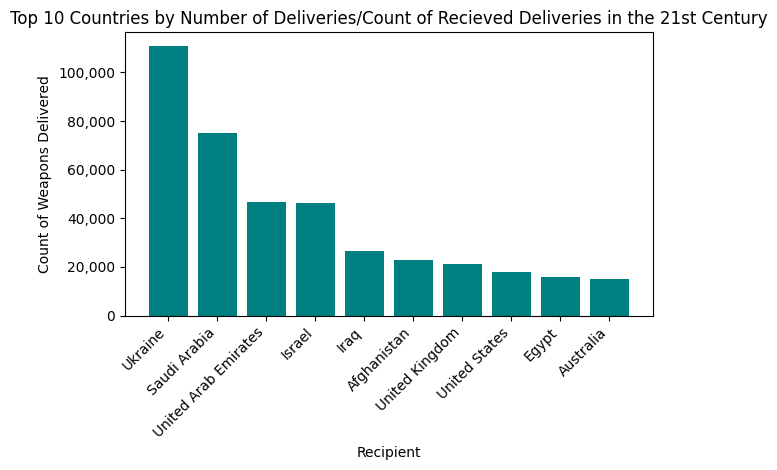

In [237]:
plt.bar(data_two.index, data_two.values, color = 'teal')
plt.xlabel('Recipient')
plt.ylabel('Count of Weapons Delivered')
plt.title('Top 10 Countries by Number of Deliveries/Count of Recieved Deliveries in the 21st Century')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.show()

data visual shows top ten suppliers

In [159]:
df_this_century.groupby('Supplier')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Supplier,
United States,546600.0
Canada,4331.0
Sweden,3210.0
Israel,2592.0
South Africa,2377.0
United Kingdom,2183.0
Germany,620.0
Bulgaria,613.0
Norway,601.0


In [160]:
data_three = df_this_century.groupby('Supplier')['Deliveries in the Year Range'].sum().nlargest(10)

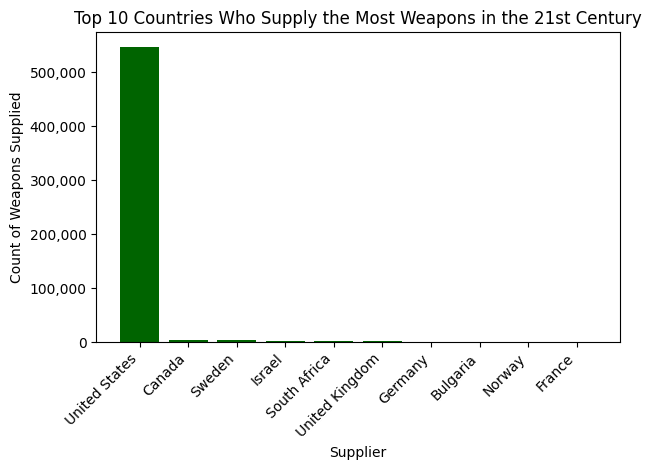

In [234]:
plt.bar (data_three.index, data_three.values, color = 'darkgreen')
plt.xlabel('Supplier')
plt.ylabel('Count of Weapons Supplied')
plt.title('Top 10 Countries Who Supply the Most Weapons in the 21st Century')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()

# US really supplying majority of the major conventional weapons worldwide...
# further visuals: see which top 5 countries is the US sending weapons to (prob Ukraine, Israel, Afghanistan from early 2000s...) -> can filter to last ten years?? 5 years?

 Lets filter to the last five years and see who US supplies the most weapons to

In [174]:
df_last_five = df[df['Year of Order'] >= 2021].sort_values(by='Year of Order', ascending=False)

In [177]:
print (df_last_five['Number Ordered'].mean())
print (df_last_five['Number Ordered'].min())
print (df_last_five['Number Ordered'].max())
print (df_last_five['Deliveries in the Year Range'].mean())
print (df_last_five['Deliveries in the Year Range'].min())
print (df_last_five['Deliveries in the Year Range'].max())

# so when comparing this to this century... we see that there are more orders and more deliveries...

319.0401284109149
1.0
29500.0
424.33125
1.0
29500.0


quick compare to entire df spanning from 1940-present... this is also prob in the . describe we did at the beginning on day 1

In [178]:
print (df['Number Ordered'].mean())
print (df['Number Ordered'].min())
print (df['Number Ordered'].max())
print (df['Deliveries in the Year Range'].mean())
print (df['Deliveries in the Year Range'].min())
print (df['Deliveries in the Year Range'].max())

# ok so the max amount of orders and deliveries was not in the last five years and wasn't in this century either

157.07810234099856
1.0
50000.0
154.80701942685414
1.0
50000.0


heres when the max amount was-- 1958; France to the US

In [184]:
df[df['Number Ordered'] == 50000.0].head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
9366,United States,France,1958,50000.0,SS-11,anti-tank missile,50000.0,NaN,New,0.01,500.0,500.0


ok back to vis.. we have to filter so we just see rows where the US was the supplier.. and only in the last five years!!!

In [190]:
df_last_five_US = df_last_five[df_last_five['Supplier'] == 'United States']
df_last_five_US.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
222,Argentina,United States,2025,50.0,Paveway,guided bomb,NaN,NaN,New,0.02,1.0,0.0
243,Australia,United States,2025,400.0,AIM-120D AMRAAM,long-range air-to-air missile,NaN,NaN,New,0.80,320.0,0.0
6235,Poland,United States,2025,8.0,AH-64D Apache Longbow,combat helicopter,8.0,2025.0,Second hand,6.20,49.6,49.6
6276,Poland,United States,2025,NaN,DB-110,aircraft reconnaissance system,NaN,NaN,New,4.00,0.0,0.0
6277,Poland,United States,2025,58.0,APG-83 SABR,combat aircraft radar,NaN,NaN,New,2.50,145.0,0.0


ok now we plot

In [192]:
df_last_five_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Ukraine,110483.0
Israel,11631.0
Australia,1432.0
Poland,1413.0
Greece,1239.0
United Arab Emirates,1106.0
Estonia,888.0
United Kingdom,859.0
France,753.0


In [193]:
data_four = df_last_five_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

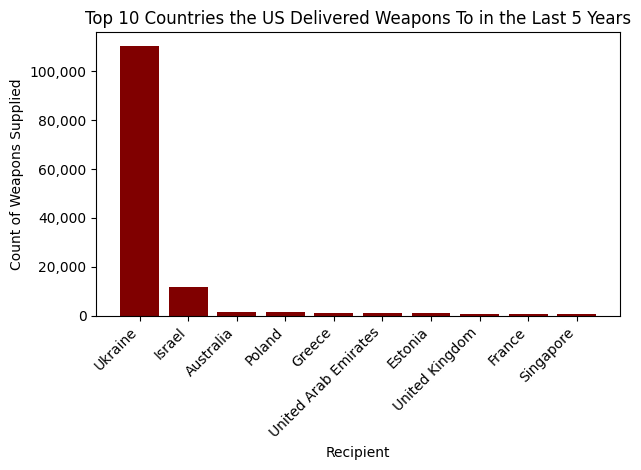

Ukraine 110483.0
Israel 11631.0
Difference 98852.0


In [257]:
plt.bar(data_four.index, data_four.values, color = 'maroon')
plt.xlabel('Recipient')
plt.ylabel('Count of Weapons Supplied')
plt.title('Top 10 Countries the US Delivered Weapons To in the Last 5 Years')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()
print ("Ukraine", data_four.values[0])
print ("Israel", data_four.values[1])
print ("Difference", data_four.values[0] - data_four.values[1])

compare the number US supplied to Ukraine and Israel with number the world supplied to Ukraine and Israel.. in the last five years as well

In [249]:
df_last_five_world = df_last_five
df_last_five_world.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
222,Argentina,United States,2025,50.0,Paveway,guided bomb,NaN,NaN,New,0.02,1.0,0.0
243,Australia,United States,2025,400.0,AIM-120D AMRAAM,long-range air-to-air missile,NaN,NaN,New,0.80,320.0,0.0
6235,Poland,United States,2025,8.0,AH-64D Apache Longbow,combat helicopter,8.0,2025.0,Second hand,6.20,49.6,49.6
6276,Poland,United States,2025,NaN,DB-110,aircraft reconnaissance system,NaN,NaN,New,4.00,0.0,0.0
6277,Poland,United States,2025,58.0,APG-83 SABR,combat aircraft radar,NaN,NaN,New,2.50,145.0,0.0


In [254]:
df_last_five_world.groupby ('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Ukraine,110483.0
Israel,11631.0
Australia,1432.0
Poland,1413.0
Greece,1239.0
United Arab Emirates,1106.0
Estonia,888.0
United Kingdom,859.0
United States,858.0


In [251]:
data_five = df_last_five_world.groupby ('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

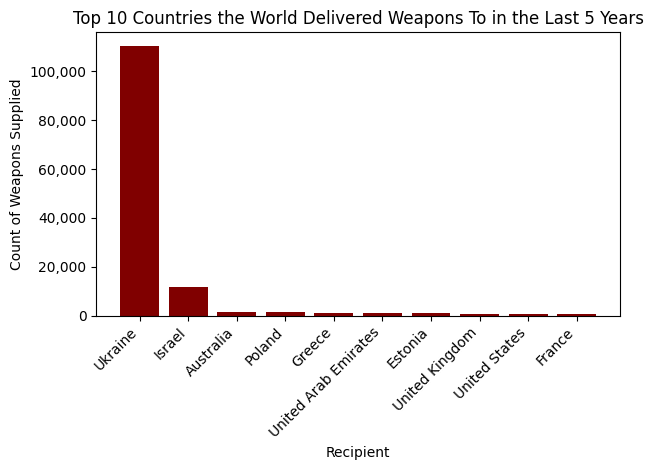

Ukraine 110483.0
Israel 11631.0
Difference 98852.0


In [260]:
plt.bar(data_five.index, data_five.values, color = 'maroon')
plt.xlabel('Recipient')
plt.ylabel('Count of Weapons Supplied')
plt.title('Top 10 Countries the World Delivered Weapons To in the Last 5 Years')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()
print ("Ukraine", data_five.values[0])
print ("Israel", data_five.values[1])
print ("Difference", data_five.values[0] - data_five.values[1])

analysis from last two plots: so Ukraine and Israel have high dependancy on US for supply of weapons. According to this dataset, US was the only supplier to these countries in the last five years and therefore makes up all of its weapons that its recieved in last five years...

dfs are filtered correctly so the dataset prob does not reflect that other countries have given weapons to Ukraine and Israel...

Will probably focus on Ukraine and Israel for project..


can look at political party/president and do analysis for both countries

Side Question: did the US (or any country) give any weapons to Ukraine in 2014 after Crimea invasion? Or did Ukraine order weapons from US and then recieve it?

note: data might not be here if ukraine needed to make an order first...
and search said that US did provide aid - but no lethal aid to Ukraine in 2014; so that explains why nothing shows up as well/confirms findings

In [218]:
df[(df['Year of Order']==2014) & (df['Recipient'].isin(['Ukraine']))].head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons


In [217]:
df[(df['Year of Order']==2014) & (df['Supplier'].isin(['United States'])) & (df['Recipient'].isin(['Ukraine']))].head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons


ok now focus on data vis that compares presidents and their aid to Ukraine and Israel??

can do the last ten years since 2016-2020 was Trump; 2020-2024 was Biden; and 2024-Now is Trump...

can compare amount of weapons delivered

can compare amount of delivered vs. ordered

Day 3

Working Research Question: TYPE HERE

start working on visuals/analysis for the research question...

do some t-tests maybe for identifying statistical significance/difference

Day 3